In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import multiprocessing as mp

import os
import ast
import re
import itertools
import pickle
import json
import datetime
import urllib.parse

from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from collections import defaultdict
from multiprocess import Pool

# Load interaction data

In [2]:
df = pd.read_excel(f"../outputs/final_outputs/triples.xlsx").drop("Unnamed: 0", axis=1)
df_isco = pd.read_excel("../outputs/final_outputs/triples_ISCO_esco.xlsx")
df_isco_cv = pd.read_excel("../outputs/final_outputs/cv_esco.xlsx")
iscos = pd.read_csv("../pipeline/data_files/isco.csv", encoding="cp850")
df_bridges = pd.read_excel("../outputs/final_outputs/bridges.xlsx")
df_CVs = pd.read_excel("../outputs/final_outputs/cv.xlsx")

In [3]:
df_int = pd.read_csv("../../dataset/final_dataset/contacted_anon.csv")

# Only keep vacancies with at least 15 interactions
relevant_vacancies = df_int["cvid"].value_counts()[df_int["cvid"].value_counts() >= 15].index

# Filter to only relevant vacancies
df_int = df_int[df_int["cvid"].isin(relevant_vacancies.values)][["humanjobid", "response", "cvid"]].fillna(0)

### TODO: TRY WHAT HAPPENS WHEN WE ONLY USE ACTUAL 1S
strict = True

if strict:
    df_int["response"] = df_int["response"].apply(lambda x: 1 if "ok" in str(x) else 0)
else:
    df_int["response"] = df_int["response"].apply(lambda x: x if x == 0 else 1)

non_zero = df_int.groupby("cvid")["response"].sum() > 0
non_zero = set(non_zero[non_zero == True].index)
len(non_zero), len(df_int.groupby("cvid"))

df_graphs = df_int[df_int["cvid"].isin(non_zero)]

In [4]:
unique_candidates = set(df_isco_cv["candidate"].dropna().unique())

def update_candidate(row):
    count = defaultdict(int)
    
    # Iterate over the specific columns (from index 3 to second-to-last)
    for entry in row.values[3:-1]:
        # Skip NaNs or non-strings to prevent eval errors
        if pd.isna(entry) or not isinstance(entry, str):
            continue
            
        try:
            # literal_eval is much safer and faster than eval()
            triples = ast.literal_eval(entry)
            for triple in triples:
                for ent in triple:
                    if ent in unique_candidates:
                        count[ent] += 1
        except (ValueError, SyntaxError):
            pass # Skip malformed strings gracefully
            
    # After checking all entries in the row, see if any hit the threshold
    for _id, val in count.items():
        if val >= 3:
            return _id  # Return the new candidate ID
            
    return row["candidate"] 

# Somewhere the cvids got mixed up. Fixing them here. 
df_isco_cv["candidate"] = df_isco_cv.apply(update_candidate, axis=1)

df_isco_cv.head()

,Unnamed: 0.1,Unnamed: 0,id,ISCO cv gemma,ESCO cv gemma,ISCO cv llama,ESCO cv llama,ISCO cv qwen,ESCO cv qwen,candidate
0,0,0,35,"[('d296ec1752b8415b903e70f37b184854', 'has_isc...","[('OCR-operatør', 'has_esco', '004333'), ('Eje...","[('3421', 'has_isco', 'it security skills;'), ...","[('Prepare oneself according to the context', ...","[('d296ec1752b8415b903e70f37b184854', 'has_isc...",[],d296ec1752b8415b903e70f37b184854
1,1,1,90,"[('2f5414d0fca34938981f8cb789e87d3c', 'has_isc...","[('2f5414d0fca34938981f8cb789e87d3c', 'has_esc...","[('HR medarbejder', 'has_isco', '8132'), ('Ser...","[('water activity', 'has_esco', 'distributed l...","[('2f5414d0fca34938981f8cb789e87d3c', 'has_isc...",[],2f5414d0fca34938981f8cb789e87d3c
2,2,2,104,"[('34adba822a9f4e59a8f994ec95fa0e64', 'has_isc...","[('34adba822a9f4e59a8f994ec95fa0e64', 'has_esc...","[('34adba822a9f4e59a8f994ec95fa0e64', 'has_isc...","[('007756', 'has_esco', '013380'), ('007756', ...","[('34adba822a9f4e59a8f994ec95fa0e64', 'has_isc...",[],34adba822a9f4e59a8f994ec95fa0e64
3,3,3,106,"[('ecaae4b36d1040fb95d930ef4ce14682', 'has_isc...","[('ecaae4b36d1040fb95d930ef4ce14682', 'has_esc...","[('ecaae4b36d1040fb95d930ef4ce14682', 'has_isc...","[('Manage sports events', 'has_esco', '001580'...","[('ecaae4b36d1040fb95d930ef4ce14682', 'has_isc...","[('give interviews to media', 'has_esco', '004...",ecaae4b36d1040fb95d930ef4ce14682
4,4,4,192,"[('b845420665d741a79b71aa42c3cb8c26', 'has_isc...","[('b845420665d741a79b71aa42c3cb8c26', 'has_esc...","[('Pensionsmedarbejder', 'has_isco', 'it secur...","[('b845420665d741a79b71aa42c3cb8c26', 'has_esc...","[('b845420665d741a79b71aa42c3cb8c26', 'has_isc...",[],b845420665d741a79b71aa42c3cb8c26


In [5]:
target_cols = df_bridges.filter(like='bridges').columns
df_bridges[target_cols] = df_bridges[target_cols].replace("[]", np.nan)
df_bridges = df_bridges.dropna(subset=target_cols, how='all')
todo_df = df_bridges[["humanjobid", "cvid"]].drop_duplicates()
df_int = df_int.merge(todo_df, on=["humanjobid", "cvid"], how="inner")

In [6]:
def clean_entity(entity):
    """Normalizes a string to lowercase, replaces spaces/hyphens with underscores, and strips symbols."""
    # Return as-is if the entity is a float/int (like 28.0)
    if not isinstance(entity, str):
        return entity
        
    # Lowercase the string
    e = entity.lower()
    
    # Remove specific symbols like '&' entirely before replacing other chars
    e = e.replace('&', '')
    
    # Replace anything that isn't a letter, number, or underscore with a space
    e = re.sub(r'[^a-z0-9_]', ' ', e)
    
    # Replace multiple spaces with a single underscore, and strip leading/trailing spaces
    e = re.sub(r'\s+', '_', e.strip())
    
    # Remove leading or trailing underscores just in case
    e = e.strip('_')
    
    return e

def clean_triples(triples):
    """Applies the cleaning function to the subject and object of each triple."""
    cleaned = []
    for sub, pred, obj in triples:
        cleaned.append((clean_entity(sub), pred, clean_entity(obj)))
    return cleaned

In [14]:
# 1. OUTERMOST LOOP: ISCO
for isco in [True, False]:
    print(f"\n{'='*50}\nSTARTING DATASET GENERATION: ISCO = {isco}\n{'='*50}")
    
    # Reset dictionaries for this specific ISCO dataset
    full_graphs = defaultdict(list)
    connected = defaultdict(lambda: defaultdict(list))

    i = 0 
    
    # 2. MODEL & PROMPT LOOPS
    for model in ["qwen", "gemma", "llama"]:
        for prompt in ["structured", "semi-structured", "unstructured"]:
            
            print(f"\n--- Processing: Model={model}, Prompt={prompt}, ISCO={isco} ---")
            
            # Track metrics just for this specific model/prompt combination
            loop_metrics = defaultdict(list)
            
            for row in tqdm(df_int.iterrows(), total=len(df_int), desc=f"Building {model} {prompt}"):
                G = nx.DiGraph()
                
                # Extract Triples
                triples_vacancy = df[df["id"] == row[1][0]][f"triples_{model}_{prompt}"].values[0]
                triples_cv = df_CVs[df_CVs["id"] == row[1][2]]["CV_triples"].values[0]
                triples_bridges = df_bridges[(df_bridges["humanjobid"] == row[1][0]) & 
                    (df_bridges["cvid"] == row[1][2])][f"bridges_{model}_{prompt}"].values[0]

                if triples_bridges == "[]":
                    pass

                # Handle ISCO logic based on the current loop state
                if isco:
                    triples_isco = df_isco[df_isco["humanjobid"] == row[1][0]][f"ISCO {model} {prompt}"].values
                    triples_isco_cv = df_isco_cv[df_isco_cv["candidate"] == row[1][2]][f"ISCO cv {model}"].values

                    # Only look for edges if not empty
                    if triples_isco: triples_isco = triples_isco[0]
                    if len(triples_isco_cv): triples_isco_cv = triples_isco_cv[0]
                    if type(triples_isco) == str: triples_isco = eval(triples_isco)
                    if type(triples_isco_cv) == str: triples_isco_cv = eval(triples_isco_cv)

                try:
                    triples_vacancy = eval(triples_vacancy)
                except:
                    triples_vacancy = []

                try:
                    triples_cv = eval(triples_cv)
                except:
                    triples_cv = []

                try:
                    triples_bridges = eval(triples_bridges)
                except:
                    triples_bridges = []
                
                if isco:                        
                    all_edges = triples_vacancy + triples_cv + triples_bridges + \
                                list(triples_isco) + list(triples_isco_cv)
                else:
                    all_edges = triples_vacancy + triples_cv + triples_bridges

                all_edges = clean_triples(all_edges)
                
                for s, p, o in all_edges:
                    G.add_edge(s, o, edge_type=p)

                # --- TOPOLOGICAL METRICS SETUP ---
                metrics = {
                    "num_nodes": G.number_of_nodes(),
                    "num_edges": G.number_of_edges(),
                    "density": 0.0,
                    "avg_degree": 0.0,
                    "avg_clustering": 0.0,
                    "path_exists": False,
                    "shortest_path_length": -1
                }

                try:
                    vacancy_node = clean_triples(triples_vacancy)[0][0]
                    cv_node = clean_triples(triples_cv)[0][0]

                    G.add_edge(f"position_{int(row[1][0])}", vacancy_node, edge_type="owl:sameAs")
                    G.add_edge(vacancy_node, f"position_{int(row[1][0])}", edge_type="owl:sameAs")

                    undirected_G = G.to_undirected()

                    vacancy_node = f"position_{int(row[1][0])}"
                    
                    G_safe = nx.Graph(undirected_G) # Flattens multi-edges
                    v_count = G_safe.number_of_nodes()
                    e_count = G_safe.number_of_edges()
                    
                    if v_count > 1:
                        metrics["density"] = nx.density(G_safe)
                        metrics["avg_degree"] = (2.0 * e_count) / v_count
                        metrics["avg_clustering"] = nx.average_clustering(G_safe)

                    if vacancy_node in undirected_G and cv_node in undirected_G:
                        has_path = nx.has_path(undirected_G, source=vacancy_node, target=cv_node)
                        metrics["path_exists"] = has_path
                        connected[model][prompt].append(has_path)
                        
                        if has_path:
                            metrics["shortest_path_length"] = nx.shortest_path_length(
                                undirected_G, source=vacancy_node, target=cv_node
                            )
                    else:
                        connected[model][prompt].append(False)
                        
                except Exception:
                    connected[model][prompt].append(False)
                    
                # --- APPEND TO DICTIONARIES ---
                full_graphs["isco"].append(isco)
                full_graphs["model"].append(model)
                full_graphs["prompt"].append(prompt)
                full_graphs["vacancy"].append(row[1][0])
                full_graphs["cvid"].append(row[1][2])
                full_graphs["response"].append(row[1][1])
                
                undirected_G.add_edge(cv_node, vacancy_node, edge_type="gets_recommended")
                undirected_G.add_edge(vacancy_node, cv_node, edge_type="gets_recommended")
                
                full_graphs["graph"].append(nx.node_link_data(undirected_G))
                
                for key, val in metrics.items():
                    full_graphs[key].append(val)
                    loop_metrics[key].append(val)
                    
            # --- PRINT METRICS AFTER EACH COMBINATION LOOP ---
            valid_paths = [p for p in loop_metrics["path_exists"]]
            valid_lengths = [l for l in loop_metrics["shortest_path_length"] if l != -1]

            total_graphs = len(valid_paths) if valid_paths else 0.0            
            path_ratio = np.mean(valid_paths) if valid_paths else 0.0
            avg_len = np.mean(valid_lengths) if valid_lengths else 0.0
            avg_nodes = np.mean(loop_metrics["num_nodes"]) if loop_metrics["num_nodes"] else 0.0
            avg_edges = np.mean(loop_metrics["num_edges"]) if loop_metrics["num_edges"] else 0.0
            avg_density = np.mean(loop_metrics["density"]) if loop_metrics["density"] else 0.0
            avg_clustering = np.mean(loop_metrics["avg_clustering"]) if loop_metrics["avg_clustering"] else 0.0

            print(f"  > Total graphs:   {int(total_graphs)}")
            print(f"  > Valid Paths:    {path_ratio:.2%}")
            print(f"  > Avg Path Len:   {avg_len:.2f} hops")
            print(f"  > Avg Graph Size: {avg_nodes:.1f} nodes, {avg_edges:.1f} edges")
            print(f"  > Avg Density:    {avg_density:.4f}")
            print(f"  > Avg Clustering: {avg_clustering:.4f}\n")

    # --- FINAL SERIALIZATION & SAVING (PER ISCO TOGGLE) ---
    print(f"All models/prompts complete for ISCO={isco}. Serializing graphs...")
    df_final = pd.DataFrame(full_graphs) 
    df_final["graph"] = df_final['graph'].apply(json.dumps)
    
    s = "strict" if strict else "easy"
    
    if isco:
        save_path = f"subgraphs_isco_no_inference_{s}.parquet"
    else:
        save_path = f"subgraphs_no_inference_{s}.parquet"

    display(df_final)
    # df_final.to_parquet(save_path)
    print(f"Saved successfully to: {save_path}\n")

print("Finished processing all ISCO combinations!")


STARTING DATASET GENERATION: ISCO = True

--- Processing: Model=qwen, Prompt=structured, ISCO=True ---


Building qwen structured:   0%|          | 0/19129 [00:00<?, ?it/s]

C:\Users\roans\AppData\Local\Temp\ipykernel_2272\570146017.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  triples_vacancy = df[df["id"] == row[1][0]][f"triples_{model}_{prompt}"].values[0]
C:\Users\roans\AppData\Local\Temp\ipykernel_2272\570146017.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  triples_cv = df_CVs[df_CVs["id"] == row[1][2]]["CV_triples"].values[0]
C:\Users\roans\AppData\Local\Temp\ipykernel_2272\570146017.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior).

  > Total graphs:   19129
  > Valid Paths:    95.61%
  > Avg Path Len:   3.14 hops
  > Avg Graph Size: 49.4 nodes, 56.4 edges
  > Avg Density:    0.0505
  > Avg Clustering: 0.0404


--- Processing: Model=qwen, Prompt=semi-structured, ISCO=True ---


Building qwen semi-structured:   0%|          | 0/19129 [00:00<?, ?it/s]

...

  > Total graphs:   19129
  > Valid Paths:    83.98%
  > Avg Path Len:   3.06 hops
  > Avg Graph Size: 47.0 nodes, 58.0 edges
  > Avg Density:    0.0553
  > Avg Clustering: 0.0492


--- Processing: Model=llama, Prompt=unstructured, ISCO=False ---


Building llama unstructured:   0%|          | 0/19129 [00:00<?, ?it/s]

  > Total graphs:   19129
  > Valid Paths:    46.10%
  > Avg Path Len:   3.55 hops
  > Avg Graph Size: 55.8 nodes, 70.2 edges
  > Avg Density:    0.0497
  > Avg Clustering: 0.0549

All models/prompts complete for ISCO=False. Serializing graphs...


,isco,model,prompt,vacancy,cvid,response,graph,num_nodes,num_edges,density,avg_degree,avg_clustering,path_exists,shortest_path_length
0,False,qwen,structured,1527549.0,1ea333bcf408489d88d6bb4ecad3852d,0,"{""directed"": false, ""multigraph"": false, ""grap...",66,71,0.032564,2.149254,0.0,True,3
1,False,qwen,structured,1527507.0,6f38a6778f1249b5b14658aed49f5348,0,"{""directed"": false, ""multigraph"": false, ""grap...",41,39,0.046458,1.904762,0.0,True,4
2,False,qwen,structured,1527507.0,238e44044b5348e09dba220756613ac6,0,"{""directed"": false, ""multigraph"": false, ""grap...",62,72,0.037378,2.317460,0.0,True,4
3,False,qwen,structured,1527507.0,6e5a9a5cac7e454bb17c85853850b108,0,"{""directed"": false, ""multigraph"": false, ""grap...",52,60,0.044267,2.301887,0.0,True,4
4,False,qwen,structured,1527507.0,2772752bd7fb4fdebd3c2cdbf7539ee7,1,"{""directed"": false, ""multigraph"": false, ""grap...",43,46,0.049683,2.136364,0.0,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172156,False,llama,unstructured,1595116.0,7fc077aa646b409a9ad42df92816bcab,0,"{""directed"": false, ""multigraph"": false, ""grap...",73,71,0.026657,1.945946,0.0,False,-1
172157,False,llama,unstructured,1598296.0,614f8e1593ce4fa9b238f18f7cd9ed45,0,"{""directed"": false, ""multigraph"": false, ""grap...",180,178,0.010988,1.977901,0.0,False,-1
172158,False,llama,unstructured,1598296.0,05cfcebebe594281a6dc6874e852aad1,0,"{""directed"": false, ""multigraph"": false, ""grap...",190,188,0.010416,1.979058,0.0,False,-1
172159,False,llama,unstructured,1598296.0,208fd8f7b17742ce820ca9f12313ddb9,0,"{""directed"": false, ""multigraph"": false, ""grap...",184,182,0.010752,1.978378,0.0,False,-1


Saved successfully to: subgraphs_no_inference_strict.parquet

Finished processing all ISCO combinations!


## Without bridge triples

In [7]:

for isco in [True, False]:
    print(f"\n{'='*50}\nSTARTING DATASET GENERATION: ISCO = {isco}\n{'='*50}")
    
    # Reset dictionaries for this specific ISCO dataset
    full_graphs = defaultdict(list)
    connected = defaultdict(lambda: defaultdict(list))

    i = 0 
    
    # 2. MODEL & PROMPT LOOPS
    for model in ["qwen", "gemma", "llama"]:
        for prompt in ["structured", "semi-structured", "unstructured"]:
            
            print(f"\n--- Processing: Model={model}, Prompt={prompt}, ISCO={isco} ---")
            
            # Track metrics just for this specific model/prompt combination
            loop_metrics = defaultdict(list)
            
            for row in tqdm(df_int.iterrows(), total=len(df_int), desc=f"Building {model} {prompt}"):
                G = nx.DiGraph()
                
                # Extract Triples
                triples_vacancy = df[df["id"] == row[1][0]][f"triples_{model}_{prompt}"].values[0]
                triples_cv = df_CVs[df_CVs["id"] == row[1][2]]["CV_triples"].values[0]
                triples_bridges = df_bridges[(df_bridges["humanjobid"] == row[1][0]) & 
                    (df_bridges["cvid"] == row[1][2])][f"bridges_{model}_{prompt}"].values[0]

                if triples_bridges == "[]":
                    pass

                # Handle ISCO logic based on the current loop state
                if isco:
                    triples_isco = df_isco[df_isco["humanjobid"] == row[1][0]][f"ISCO {model} {prompt}"].values
                    triples_isco_cv = df_isco_cv[df_isco_cv["candidate"] == row[1][2]][f"ISCO cv {model}"].values

                    # Only look for edges if not empty
                    if triples_isco: triples_isco = triples_isco[0]
                    if len(triples_isco_cv): triples_isco_cv = triples_isco_cv[0]
                    if type(triples_isco) == str: triples_isco = eval(triples_isco)
                    if type(triples_isco_cv) == str: triples_isco_cv = eval(triples_isco_cv)

                try:
                    triples_vacancy = eval(triples_vacancy)
                except:
                    triples_vacancy = []

                try:
                    triples_cv = eval(triples_cv)
                except:
                    triples_cv = []

                try:
                    triples_bridges = [] 
                except:
                    triples_bridges = []
                
                if isco:                        
                    all_edges = triples_vacancy + triples_cv + triples_bridges + \
                                list(triples_isco) + list(triples_isco_cv)
                else:
                    all_edges = triples_vacancy + triples_cv + triples_bridges

                all_edges = clean_triples(all_edges)
                
                for s, p, o in all_edges:
                    G.add_edge(s, o, edge_type=p)

                # --- TOPOLOGICAL METRICS SETUP ---
                metrics = {
                    "num_nodes": G.number_of_nodes(),
                    "num_edges": G.number_of_edges(),
                    "density": 0.0,
                    "avg_degree": 0.0,
                    "avg_clustering": 0.0,
                    "path_exists": False,
                    "shortest_path_length": -1
                }

                try:
                    vacancy_node = clean_triples(triples_vacancy)[0][0]
                    cv_node = clean_triples(triples_cv)[0][0]

                    G.add_edge(f"position_{int(row[1][0])}", vacancy_node, edge_type="owl:sameAs")
                    G.add_edge(vacancy_node, f"position_{int(row[1][0])}", edge_type="owl:sameAs")

                    undirected_G = G.to_undirected()

                    vacancy_node = f"position_{int(row[1][0])}"
                    
                    G_safe = nx.Graph(undirected_G) # Flattens multi-edges
                    v_count = G_safe.number_of_nodes()
                    e_count = G_safe.number_of_edges()
                    
                    if v_count > 1:
                        metrics["density"] = nx.density(G_safe)
                        metrics["avg_degree"] = (2.0 * e_count) / v_count
                        metrics["avg_clustering"] = nx.average_clustering(G_safe)

                    if vacancy_node in undirected_G and cv_node in undirected_G:
                        has_path = nx.has_path(undirected_G, source=vacancy_node, target=cv_node)
                        metrics["path_exists"] = has_path
                        connected[model][prompt].append(has_path)
                        
                        if has_path:
                            metrics["shortest_path_length"] = nx.shortest_path_length(
                                undirected_G, source=vacancy_node, target=cv_node
                            )
                    else:
                        connected[model][prompt].append(False)
                        
                except Exception:
                    connected[model][prompt].append(False)
                    
                # --- APPEND TO DICTIONARIES ---
                full_graphs["isco"].append(isco)
                full_graphs["model"].append(model)
                full_graphs["prompt"].append(prompt)
                full_graphs["vacancy"].append(row[1][0])
                full_graphs["cvid"].append(row[1][2])
                full_graphs["response"].append(row[1][1])
                
                undirected_G.add_edge(cv_node, vacancy_node, edge_type="gets_recommended")
                undirected_G.add_edge(vacancy_node, cv_node, edge_type="gets_recommended")
                
                full_graphs["graph"].append(nx.node_link_data(undirected_G))
                
                for key, val in metrics.items():
                    full_graphs[key].append(val)
                    loop_metrics[key].append(val)
                    
            # --- PRINT METRICS AFTER EACH COMBINATION LOOP ---
            valid_paths = [p for p in loop_metrics["path_exists"]]
            valid_lengths = [l for l in loop_metrics["shortest_path_length"] if l != -1]

            total_graphs = len(valid_paths) if valid_paths else 0.0            
            path_ratio = np.mean(valid_paths) if valid_paths else 0.0
            avg_len = np.mean(valid_lengths) if valid_lengths else 0.0
            avg_nodes = np.mean(loop_metrics["num_nodes"]) if loop_metrics["num_nodes"] else 0.0
            avg_edges = np.mean(loop_metrics["num_edges"]) if loop_metrics["num_edges"] else 0.0
            avg_density = np.mean(loop_metrics["density"]) if loop_metrics["density"] else 0.0
            avg_clustering = np.mean(loop_metrics["avg_clustering"]) if loop_metrics["avg_clustering"] else 0.0

            print(f"  > Total graphs:   {int(total_graphs)}")
            print(f"  > Valid Paths:    {path_ratio:.2%}")
            print(f"  > Avg Path Len:   {avg_len:.2f} hops")
            print(f"  > Avg Graph Size: {avg_nodes:.1f} nodes, {avg_edges:.1f} edges")
            print(f"  > Avg Density:    {avg_density:.4f}")
            print(f"  > Avg Clustering: {avg_clustering:.4f}\n")

    display(df_final)

print("Finished processing all ISCO combinations!")


STARTING DATASET GENERATION: ISCO = True

--- Processing: Model=qwen, Prompt=structured, ISCO=True ---


Building qwen structured:   0%|          | 0/19129 [00:00<?, ?it/s]

C:\Users\roans\AppData\Local\Temp\ipykernel_14812\1806219000.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  triples_vacancy = df[df["id"] == row[1][0]][f"triples_{model}_{prompt}"].values[0]
C:\Users\roans\AppData\Local\Temp\ipykernel_14812\1806219000.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  triples_cv = df_CVs[df_CVs["id"] == row[1][2]]["CV_triples"].values[0]
C:\Users\roans\AppData\Local\Temp\ipykernel_14812\1806219000.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

  > Total graphs:   19129
  > Valid Paths:    66.04%
  > Avg Path Len:   2.90 hops
  > Avg Graph Size: 43.2 nodes, 41.6 edges
  > Avg Density:    0.0490
  > Avg Clustering: 0.0030


--- Processing: Model=qwen, Prompt=semi-structured, ISCO=True ---


Building qwen semi-structured:   0%|          | 0/19129 [00:00<?, ?it/s]

...

Building llama semi-structured:   0%|          | 0/19129 [00:00<?, ?it/s]

  > Total graphs:   19129
  > Valid Paths:    80.17%
  > Avg Path Len:   3.04 hops
  > Avg Graph Size: 67.5 nodes, 66.5 edges
  > Avg Density:    0.0339
  > Avg Clustering: 0.0092


--- Processing: Model=llama, Prompt=unstructured, ISCO=True ---


Building llama unstructured:   0%|          | 0/19129 [00:00<?, ?it/s]

  > Total graphs:   19129
  > Valid Paths:    23.53%
  > Avg Path Len:   3.24 hops
  > Avg Graph Size: 74.8 nodes, 73.3 edges
  > Avg Density:    0.0310
  > Avg Clustering: 0.0157



NameError: name 'df_final' is not defined

In [10]:
def plot_clean_graph(G, output_filename="sub_graph_no_inference.pdf"):
    # 0. SET PUBLICATION PARAMETERS
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'figure.dpi': 300 
    })
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 1. REMOVE SELF-LOOPS
    display_G = G.copy()
    display_G.remove_edges_from(nx.selfloop_edges(display_G))
    
    # 2. POSITIONAL LAYOUT
    pos = nx.kamada_kawai_layout(display_G)
    
    # 3. DRAW NODES
    nx.draw_networkx_nodes(
        display_G, pos,
        ax=ax,
        node_size=350,
        node_color='#4C72B0',
        edgecolors='black',
        linewidths=1.0
    )
    
    # 4. DRAW EDGES
    nx.draw_networkx_edges(
        display_G, pos,
        ax=ax,
        alpha=0.6,
        edge_color='#555555',
        arrows=True,
        arrowsize=12,
        arrowstyle='-|>',
        width=1.2,
        connectionstyle='arc3,rad=0.05' 
    )
    
    # 4.5 DRAW EDGE LABELS
    # IMPORTANT: Change 'label' to whatever key your edge data uses (e.g., 'weight', 'relation')
    edge_labels = {k: v.lower() for k, v in nx.get_edge_attributes(display_G, 'edge_type').items()}
    
    nx.draw_networkx_edge_labels(
        display_G, pos,
        edge_labels=edge_labels,
        ax=ax,
        font_size=7,
        font_color='#B22222', # Dark red to stand out from nodes/edges
        bbox=dict(alpha=0.8, color='white', edgecolor='none', pad=0.5) # White background so lines don't obscure text
    )
    
    # 5. CLEAN LABELS
    labels = {n: str(n).replace("jie:", "").replace("_jie_", "").split('/')[-1][:20] 
              for n in display_G.nodes()}
    
    nx.draw_networkx_labels(
        display_G, pos, labels,
        ax=ax,
        font_size=8,
        font_weight='bold',
        font_color='black'
    )
    
    # 6. FINALIZE & EXPORT
    ax.axis('off')
    plt.tight_layout() 
    
    plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\drawing\nx_pylab.py:1375: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  super().__init__(self.x, self.y, *args, rotation=self.angle, **kwargs)


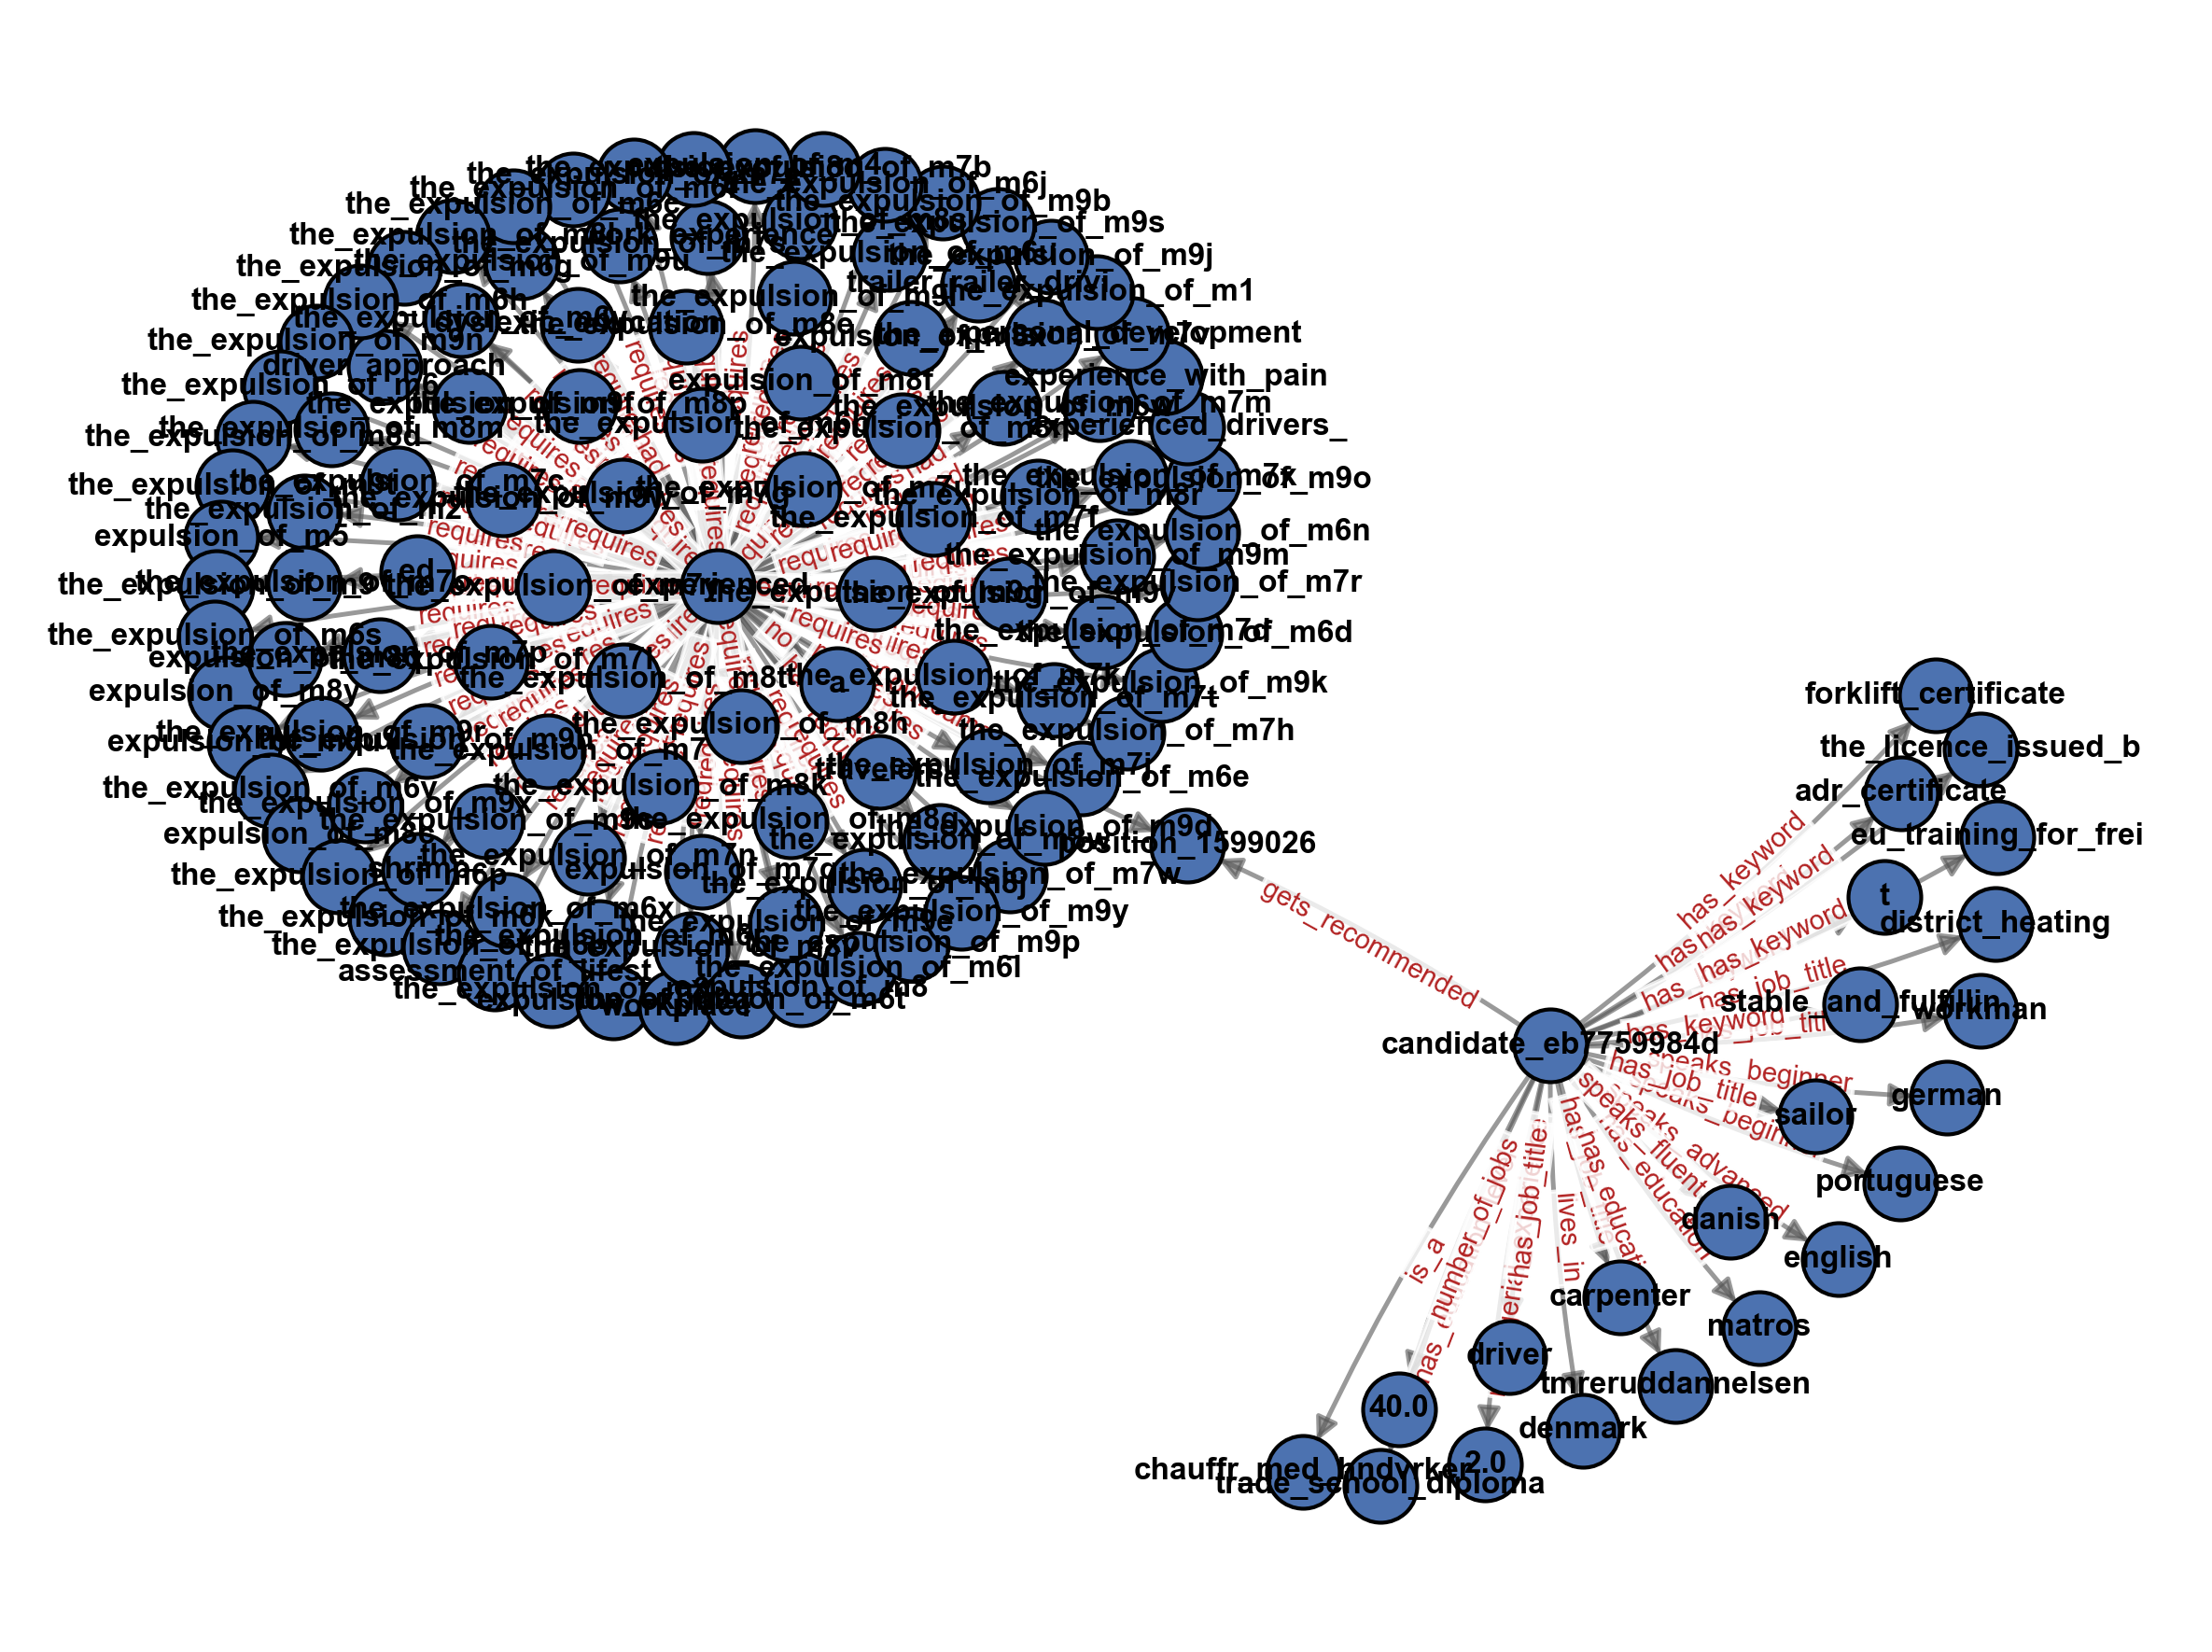

In [13]:
plot_clean_graph(undirected_G)

In [14]:
undirected_G.nodes

NodeView(('experienced', 'the_expulsion_of_m7w', 'the_expulsion_of_m8w', 'the_expulsion_of_m6e', 'the_expulsion_of_m7h', 'the_expulsion_of_m9k', 'the_expulsion_of_m9g', 'the_expulsion_of_m7u', 'expulsion_of_m8f', 'the_expulsion_of_m8n', 'the_expulsion_of_m7f', 'the_expulsion_of_m9v', 'the_expulsion_of_m7d', 'the_expulsion_of_m6d', 'the_expulsion_of_m7r', 'the_expulsion_of_m9m', 'the_expulsion_of_m6n', 'the_expulsion_of_m7x', 'the_expulsion_of_m9o', 'the_expulsion_of_m8r', 'experienced_drivers_for_towing_railer', 'the_expulsion_of_m7m', 'the_expulsion_of_m6w', 'experience_with_paintwork', 'the_expulsion_of_m7v', 'personal_development_objectives', 'the_expulsion_of_m1', 'trailer_railer_driving', 'the_expulsion_of_m9j', 'the_expulsion_of_m9s', 'expulsion_of_m8x', 'the_expulsion_of_m9b', 'the_expulsion_of_m9l', 'the_expulsion_of_m6u', 'the_expulsion_of_m6j', 'the_expulsion_of_m8s', 'work_experience', 'the_expulsion_of_m7b', 'expulsion_of_m4', 'the_expulsion_of_m8e', 'the_expulsion_of_m8o',